In [ ]:
import tdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyranges as pr
from sklearn.decomposition import PCA
import seaborn as sb
from scipy.stats import pearsonr

# custom TODO: decide if including these, if not used since we also include the full input labels then don't include here
from QC_utils import * # my QC functions

from analysis_utils import *

In [2]:
updated_labels = pd.read_csv('final_labels_manuscript.tsv', sep='\t')
updated_labels

/tmp/ipykernel_1119304/743217758.py:1: DtypeWarning: Columns (3,9,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  updated_labels = pd.read_csv('final_labels_manuscript.tsv', sep='\t')


,start,end,LocusID,mei_id,start_mei,end_mei,mei_family,mei_subfamily,orientation,divergence,...,terminal_label,GencodeGeneRegion,RefseqGeneRegion,ManeGeneRegion,disease_id,genomic_annotation,keep_rel_pos,mei_family_plot,simple_motif,base_composition
0,26931,26941,26.0,19.0,26791.0,27053.0,SINE_Alu,AluSp,+,9.5,...,internal,intergenic,intron,intergenic,non_disease_associated,intron,True,Alu,ACC,AC
1,27862,27872,27.0,21.0,27833.0,28014.0,SINE_MIR,MIRb,C,33.6,...,internal,intergenic,intron,intergenic,non_disease_associated,intron,True,SINE_MIR,ATC,ACT
2,28245,28255,28.0,22.0,28151.0,28302.0,SINE_MIR,MIR,C,32.0,...,internal,intergenic,intron,intergenic,non_disease_associated,intron,True,SINE_MIR,ACT,ACT
3,30866,30892,34.0,26.0,30694.0,30848.0,LTR_ERVL-MaLR,MLT1A,+,18.7,...,3'terminal,intron,intron,intergenic,non_disease_associated,intron,True,LTR_ERVL-MaLR,AG,AG
4,30934,30948,36.0,26.0,30953.0,31131.0,LTR_ERVL-MaLR,MLT1A,+,18.7,...,5'terminal,intron,intron,intergenic,non_disease_associated,intron,True,LTR_ERVL-MaLR,AG,AG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2430013,56694117,56694136,4542235.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,non_mei,intergenic,intergenic,intergenic,NaN,NaN,True,non-MEI,AATGG,AGT
2430014,56694220,56694236,4542236.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,non_mei,intergenic,intergenic,intergenic,NaN,NaN,True,non-MEI,AATGG,AGT
2430015,56694332,56694350,4542237.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,non_mei,intergenic,intergenic,intergenic,NaN,NaN,True,non-MEI,AATGG,AGT
2430016,56694378,56694395,4542238.0,non_mei,NaN,NaN,non_mei,non_mei,non_mei,non_mei,...,non_mei,intergenic,intergenic,intergenic,NaN,NaN,True,non-MEI,AATGG,AGT


In [10]:
plot_out = "/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/manuscript_figures/figure_1"
main_families = ["non_mei", "Retroposon_SVA", "LINE_L1", "LINE_L2", "SINE_Alu"]
updated_labels["mei_family_plot"] = updated_labels["mei_family"].replace({
    "non_mei": "non-MEI",
    "Retroposon_SVA": "SVA",
    "LINE_L1": "LINE1",
    "LINE_L2": "LINE2",
    "SINE_Alu": "Alu"
})
family_orders = ["non-MEI", "Alu", "LINE1", "LINE2", "SVA"]

# Figure 1A

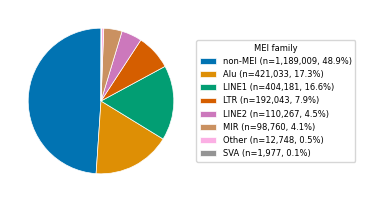

In [6]:
# redo the pie chart we have to use tab 20 since the current colors are not very distinct
# plot a pie chart of mei_family

# map the names to non-MEI-STR (non_mei), Alu-STR, LINE1-STR, LTR-STR (mei_family contains LTR), LINE2-STR, MIR-STR, SVA-STR, and Other based on if the mei_family column contains the first string before the -STR
updated_labels['mei_family_mapped'] = updated_labels['mei_family'].apply(lambda x: 'non-MEI' if x == 'non_mei' else x)
updated_labels['mei_family_mapped'] = updated_labels['mei_family_mapped'].apply(lambda x: 'Alu' if 'Alu' in x else x)
updated_labels['mei_family_mapped'] = updated_labels['mei_family_mapped'].apply(lambda x: 'LINE1' if 'L1' in x else x)
updated_labels['mei_family_mapped'] = updated_labels['mei_family_mapped'].apply(lambda x: 'LTR' if 'LTR' in x else x)
updated_labels['mei_family_mapped'] = updated_labels['mei_family_mapped'].apply(lambda x: 'LINE2' if 'L2' in x else x)
updated_labels['mei_family_mapped'] = updated_labels['mei_family_mapped'].apply(lambda x: 'MIR' if 'MIR' in x else x)
updated_labels['mei_family_mapped'] = updated_labels['mei_family_mapped'].apply(lambda x: 'SVA' if 'SVA' in x else x)
updated_labels['mei_family_mapped'] = updated_labels['mei_family_mapped'].apply(lambda x: 'Other' if x not in ['non-MEI', 'Alu', 'LINE1', 'LTR', 'LINE2', 'MIR', 'SVA'] else x)

counts = updated_labels.mei_family_mapped.value_counts()
colors = plt.cm.tab20.colors[: len(counts)]
colors = plt.cm.tab10.colors[: len(counts)]
sb.set_palette("colorblind") 
# get the current color palette as a list of colors
current_palette = sb.color_palette()
colors = [color for color in current_palette]
fig, ax = plt.subplots(figsize=(4, 2))
wedges, _ = ax.pie(
    counts,
    labels=None,
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 0.5}
)
# Create legend labels with counts and percentages
legend_labels = [f"{label} (n={count:,}, {100*count/counts.sum():.1f}%)" for label, count in counts.items()]

ax.legend(
    wedges,
    legend_labels,
    title="MEI family",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(plot_out + "/mei_family_pie_chart.pdf", dpi=300, bbox_inches="tight")
plt.show()

# make this figure with fot size 6pt and 3 inches across and save it as a pdf with the name "mei_family_pie_chart.pdf" at 300 dpi
plt.rcParams.update({'font.size': 6})
# plt.gcf().set_size_inches(4,2)
# plt.savefig(plot_out + "/mei_family_pie_chart.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Figure 1C

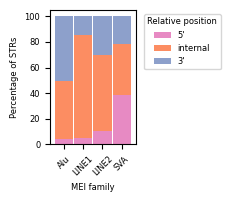

In [8]:
terminal_counts = updated_labels[(updated_labels.mei_family.isin(main_families))&(updated_labels.keep_rel_pos==True)&(updated_labels.terminal_label.isin(["5'terminal", "3'terminal", "internal"]))].groupby(["mei_family_plot", "terminal_label"]).size().unstack(fill_value=0)
terminal_counts_percent = terminal_counts.div(terminal_counts.sum(axis=1), axis=0) * 100
terminal_counts_percent = terminal_counts_percent[["5'terminal", "internal","3'terminal"]]
terminal_counts_percent.plot(
    kind="bar",
    stacked=True,
    color=[sb.color_palette("Set2")[3], sb.color_palette("Set2")[1], sb.color_palette("Set2")[2]],
    figsize=(7/3,2),
    width=0.95,
    align='center'
)
plt.xlabel("MEI family")
plt.ylabel("Percentage of STRs")
# rotate the x-axis labels 45 degrees
plt.xticks(rotation=45)
# plt.title("Percentage of STRs per relative position by MEI family")
plt.legend(title="Relative position", labels=["5'", "internal", "3'"], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# save out the figure
plt.savefig(plot_out + "/relative_position.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Figure 1D

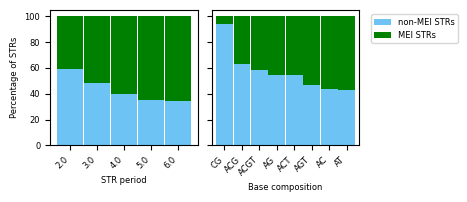

In [9]:
plt.rcParams.update({'font.size': 6})
fig, axes = plt.subplots(1, 2, figsize=(2*7/3, 2), sharey=True)
non_mei_color = "#6cc3f4"
# period subplot
period_counts = updated_labels[updated_labels.str_period < 7].groupby(["str_period", "mei"]).size().unstack(fill_value=0)
period_counts_percent = period_counts.div(period_counts.sum(axis=1), axis=0) * 100
period_counts_percent.plot(
    kind="bar",
    stacked=True,
    color=[non_mei_color, "green"],
    width=0.95,
    align='center',
    ax=axes[0]
)
axes[0].set_xlabel("STR period", fontsize=6)
axes[0].set_ylabel("Percentage of STRs", fontsize=6)
axes[0].set_xticks(range(len(period_counts_percent.index)))
axes[0].set_xticklabels(period_counts_percent.index, rotation=45, ha='right', fontsize=6)
# axes[0].set_title("Period", fontsize=7)

# base composition subplot
base_counts = updated_labels[updated_labels.base_composition != "CGN"].groupby(["base_composition", "mei"]).size().unstack(fill_value=0)
base_counts_percent = base_counts.div(base_counts.sum(axis=1), axis=0) * 100
base_counts_percent.sort_values(by=False, ascending=False).plot(
    kind="bar",
    stacked=True,
    color=[non_mei_color, "green"],
    width=0.95,
    align='center',
    ax=axes[1]
)
axes[1].set_xlabel("Base composition", fontsize=6)
axes[1].set_xticks(range(len(base_counts_percent.index)))
axes[1].set_xticklabels(base_counts_percent.sort_values(by=False, ascending=False).index, rotation=45, ha='right', fontsize=6)
# axes[1].set_title("Base composition", fontsize=7)

# legend and layout
axes[0].legend().remove()
axes[1].legend(title="", labels=["non-MEI STRs", "MEI STRs"], bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6, title_fontsize=6)
plt.tight_layout()
# save out the figure
plt.savefig(plot_out + "/annotation_figures.pdf", dpi=300, bbox_inches='tight')
plt.show()


# Figure 1 E

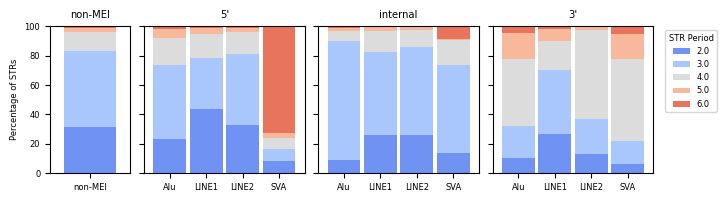

In [11]:
terminal_labels_order = ["5'terminal", "internal", "3'terminal"]
family_plot_order = family_orders[1:]  # ["Alu", "LINE1", "LINE2", "SVA"]

terminal_period_counts = updated_labels[
    (updated_labels.mei_family.isin(main_families))
    & (updated_labels.keep_rel_pos == True)
    & (updated_labels.terminal_label.isin(terminal_labels_order))
].groupby(["mei_family_plot", "terminal_label", "str_period"]).size().unstack(fill_value=0)

terminal_period_counts_percent = terminal_period_counts.div(
    terminal_period_counts.sum(axis=1), axis=0
) * 100

period_order = sorted(terminal_period_counts_percent.columns)
period_colors = sb.color_palette("coolwarm", n_colors=len(period_order))

nonmei_period_counts = updated_labels[
    (updated_labels.mei_family == "non_mei")
    & updated_labels.str_period.notna()
].groupby("str_period").size()
nonmei_period_percent = nonmei_period_counts.div(nonmei_period_counts.sum()) * 100
nonmei_period_percent = nonmei_period_percent.reindex(period_order).fillna(0)
bar_width = 0.9
fig, axes = plt.subplots(1, len(terminal_labels_order) + 1, figsize=(7.24, 2))

# recreate the axes with a narrower first subplot and share y with the leftmost axis
for ax in axes:
    ax.remove()
gs = fig.add_gridspec(1, len(terminal_labels_order) + 1, width_ratios=[0.5] + [1] * len(terminal_labels_order))
axes = [fig.add_subplot(gs[0, 0])]
axes += [fig.add_subplot(gs[0, i], sharey=axes[0]) for i in range(1, len(terminal_labels_order) + 1)]

nonmei_df = pd.DataFrame([nonmei_period_percent], index=["non-MEI"])
nonmei_df.plot(
    kind="bar",
    stacked=True,
    color=period_colors,
    width=bar_width,
    align="center",
    ax=axes[0],
    legend=False
)
axes[0].set_title("non-MEI")
axes[0].set_xlabel("")
axes[0].set_xticklabels(["non-MEI"], rotation=0, ha="center")
axes[0].set_ylabel("Percentage of STRs")
axes[0].set_ylim(0, 100)

for ax, terminal_label in zip(axes[1:], terminal_labels_order):
    term_df = terminal_period_counts_percent.xs(terminal_label, level="terminal_label")
    term_df = term_df.reindex(family_plot_order)[period_order]

    term_df.plot(
        kind="bar",
        stacked=True,
        color=period_colors,
        width=bar_width,
        align="center",
        ax=ax,
        legend=False
    )

    ax.set_title(terminal_label.replace("terminal", "").replace("'", "'"))
    ax.set_xlabel("")
    ax.set_ylabel("Percentage of STRs" if ax is axes[1] else "")
    ax.set_ylim(0, 100)
    ax.set_xticklabels(family_plot_order, rotation=0, ha="center")

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, title="STR Period", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
# save the figure
plt.savefig(plot_out + "/period_relative_manuscript.pdf", dpi=300, bbox_inches="tight")
plt.show()


# Figure 1F

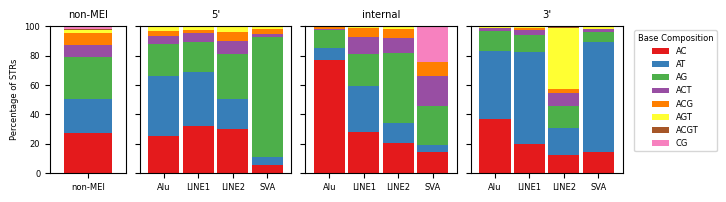

In [12]:
# non-MEI + terminal-position faceted base composition stacked bars
terminal_labels_order = ["5'terminal", "internal", "3'terminal"]
family_plot_order = family_orders[1:]  # ["Alu", "LINE1", "LINE2", "SVA"]

terminal_base_counts = updated_labels[
    (updated_labels.mei_family.isin(main_families))
    & (updated_labels.keep_rel_pos == True)
    & (updated_labels.terminal_label.isin(terminal_labels_order))
    & (updated_labels.base_composition != "CGN")
].groupby(["mei_family_plot", "terminal_label", "base_composition"]).size().unstack(fill_value=0)

terminal_base_counts_percent = terminal_base_counts.div(
    terminal_base_counts.sum(axis=1), axis=0
) * 100

base_order = terminal_base_counts.sum(axis=0).sort_values(ascending=False).index
base_colors = sb.color_palette("Set1", n_colors=len(base_order))

# non-MEI distribution
nonmei_base_counts = updated_labels[
    (updated_labels.mei_family == "non_mei")
    & updated_labels.base_composition.notna()
    & (updated_labels.base_composition != "CGN")
].groupby("base_composition").size()
nonmei_base_percent = nonmei_base_counts.div(nonmei_base_counts.sum()) * 100
nonmei_base_percent = nonmei_base_percent.reindex(base_order).fillna(0)

bar_width = 0.9
fig, axes = plt.subplots(1, len(terminal_labels_order) + 1, figsize=(7.24, 2))

# recreate the axes with a narrower first subplot and share y with the leftmost axis
for ax in axes:
    ax.remove()
gs = fig.add_gridspec(1, len(terminal_labels_order) + 1, width_ratios=[0.5] + [1] * len(terminal_labels_order))
axes = [fig.add_subplot(gs[0, 0])]
axes += [fig.add_subplot(gs[0, i], sharey=axes[0]) for i in range(1, len(terminal_labels_order) + 1)]

nonmei_df = pd.DataFrame([nonmei_base_percent], index=["non-MEI"])
nonmei_df.plot(
    kind="bar",
    stacked=True,
    color=base_colors,
    width=bar_width,
    align="center",
    ax=axes[0],
    legend=False
)
axes[0].set_title("non-MEI")
axes[0].set_xlabel("")
axes[0].set_xticklabels(["non-MEI"], rotation=0, ha="center")
axes[0].set_ylabel("Percentage of STRs")
axes[0].set_ylim(0, 100)

for ax, terminal_label in zip(axes[1:], terminal_labels_order):
    term_df = terminal_base_counts_percent.xs(terminal_label, level="terminal_label")
    term_df = term_df.reindex(family_plot_order).fillna(0)[base_order]

    term_df.plot(
        kind="bar",
        stacked=True,
        color=base_colors,
        width=bar_width,
        align="center",
        ax=ax,
        legend=False
    )

    ax.set_title(terminal_label.replace("terminal", "").replace("'", "'"))
    ax.set_xlabel("")
    ax.set_ylabel("Percentage of STRs" if ax is axes[1] else "")
    ax.set_ylim(0, 100)
    ax.set_xticklabels(family_plot_order, rotation=0, ha="center")

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, title="Base Composition", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.savefig(plot_out + "/base_composition_rel_pos_nonmei.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Supplemental 1

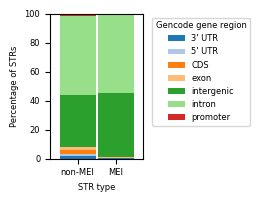

In [13]:
plt.rcParams.update({'font.size': 6})
fig, axes = plt.subplots(1, 2, figsize=(7.24/2, 2), sharey=True)

# plot the period subplot
gencode_counts = updated_labels[updated_labels.GencodeGeneRegion.notna()].groupby(["mei", "GencodeGeneRegion"]).size().unstack(fill_value=0)
gencode_counts_percent = gencode_counts.div(gencode_counts.sum(axis=1), axis=0) * 100
gencode_counts_percent.plot(
    kind="bar",
    stacked=True,
    color=sb.color_palette("tab20", n_colors=gencode_counts_percent.shape[1]),
    width=0.95,
    align="center",
    ax=axes[0],
    legend=False
)
axes[0].set_xlabel("STR type", fontsize=6)
axes[0].set_ylabel("Percentage of STRs", fontsize=6)
axes[0].set_xticklabels(["non-MEI", "MEI"], rotation=0, ha='center', fontsize=6)
axes[0].set_ylim(0, 100)

# add legend on the second subplot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, title="Gencode gene region", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6, title_fontsize=6)
axes[1].remove()

plt.tight_layout()
plt.savefig(plot_out + "/gencode_gene_region.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Calculations for text and Supplemental flow chart

In [27]:
# number of overall regions included
print(f"Number of overall regions included: {updated_labels.shape[0]}\n")
# print the percentage of regions that are mei vs non-mei
mei_count = updated_labels[updated_labels.mei == True].shape[0]
non_mei_count = updated_labels[updated_labels.mei == False].shape[0]
print(f"Percentage of MEI STRs: {mei_count / updated_labels.shape[0]:.2%}")
print(f"Percentage of non-MEI STRs: {non_mei_count / updated_labels.shape[0]:.2%}\n")
# Percentage of regions from TRExplorer catalog v1 (according to preprint), overall and by period
overall_perc= updated_labels.shape[0] / (978972 + 649612 + 1432117 + 590787 + 177422 + 56731)
dinuc = updated_labels[updated_labels.str_period == 2].shape[0]/978972
trinucl = updated_labels[updated_labels.str_period == 3].shape[0]/1432117
tetranucl = updated_labels[updated_labels.str_period == 4].shape[0]/590787
pentanucl = updated_labels[updated_labels.str_period == 5].shape[0]/177422
hexanucl = updated_labels[updated_labels.str_period == 6].shape[0]/56731

print("Percentage of regions included from TRExplorer catalog v1 (according to preprint), overall and by period:")
print(f"Overall percentage: {overall_perc:.2%}")
print(f"Dinucleotide percentage: {dinuc:.2%}")
print(f"Trinucleotide percentage: {trinucl:.2%}")
print(f"Tetranucleotide percentage: {tetranucl:.2%}")
print(f"Pentanucleotide percentage: {pentanucl:.2%}")
print(f"Hexanucleotide percentage: {hexanucl:.2%}")



Number of overall regions included: 2430018

Percentage of MEI STRs: 51.07%
Percentage of non-MEI STRs: 48.93%

Percentage of regions included from TRExplorer catalog v1 (according to preprint), overall and by period:
Overall percentage: 62.54%
Dinucleotide percentage: 65.25%
Trinucleotide percentage: 88.49%
Tetranucleotide percentage: 65.54%
Pentanucleotide percentage: 59.61%
Hexanucleotide percentage: 54.64%
Percentage of MEI STRs by period:
  Dinucleotide: 40.92%, Non-coding: 41.77%
  Trinucleotide: 51.95%, Non-coding: 54.82%
  Tetranucleotide: 60.02%, Non-coding: 60.89%
  Pentanucleotide: 64.71%, Non-coding: 65.82%
  Hexanucleotide: 66.02%, Non-coding: 68.41%
  Periods 4-6: 62.32%
Percentage of non-MEI STRs by period:
  Dinucleotide: 59.08%, Non-coding: 58.23%
  Trinucleotide: 48.05%, Non-coding: 45.18%
  Tetranucleotide: 39.98%, Non-coding: 39.11%
  Pentanucleotide: 35.29%, Non-coding: 34.18%
  Hexanucleotide: 33.98%, Non-coding: 31.59%
  Periods 4-6: 37.68%

Percentage of non_mei

In [29]:
# Percentage by of each STR type by mei_family that are each period
# just non_mei vs mei periods
for mei_flag in [True, False]:
    print(f"Percentage of {'MEI' if mei_flag else 'non-MEI'} STRs by period:")
    mei_labels = updated_labels[updated_labels.mei == mei_flag]
    mei_dinuc = mei_labels[mei_labels.str_period == 2].shape[0]/updated_labels[updated_labels.str_period == 2].shape[0]
    mei_trinucl = mei_labels[mei_labels.str_period == 3].shape[0]/updated_labels[updated_labels.str_period == 3].shape[0]
    mei_tetranucl = mei_labels[mei_labels.str_period == 4].shape[0]/updated_labels[updated_labels.str_period == 4].shape[0]
    mei_pentanucl = mei_labels[mei_labels.str_period == 5].shape[0]/updated_labels[updated_labels.str_period == 5].shape[0]
    mei_hexanucl = mei_labels[mei_labels.str_period == 6].shape[0]/updated_labels[updated_labels.str_period == 6].shape[0]

    # also get the percentages for just non-coding regions (GencodeGeneRegion == 'intergenic' or GencodeGeneRegion == 'intron')
    non_coding_labels = mei_labels[(mei_labels.GencodeGeneRegion == 'intergenic') | (mei_labels.GencodeGeneRegion == 'intron')]
    non_coding_overall = updated_labels[(updated_labels.GencodeGeneRegion == 'intergenic') | (updated_labels.GencodeGeneRegion == 'intron')]
    non_coding_dinuc = non_coding_labels[non_coding_labels.str_period == 2].shape[0]/non_coding_overall[non_coding_overall.str_period == 2].shape[0]
    non_coding_trinucl = non_coding_labels[non_coding_labels.str_period == 3].shape[0]/non_coding_overall[non_coding_overall.str_period == 3].shape[0]
    non_coding_tetranucl = non_coding_labels[non_coding_labels.str_period == 4].shape[0]/non_coding_overall[non_coding_overall.str_period == 4].shape[0]
    non_coding_pentanucl = non_coding_labels[non_coding_labels.str_period == 5].shape[0]/non_coding_overall[non_coding_overall.str_period == 5].shape[0]
    non_coding_hexanucl = non_coding_labels[non_coding_labels.str_period == 6].shape[0]/non_coding_overall[non_coding_overall.str_period == 6].shape[0]

    print(f"  Dinucleotide: {mei_dinuc:.2%}, Non-coding: {non_coding_dinuc:.2%}")
    print(f"  Trinucleotide: {mei_trinucl:.2%}, Non-coding: {non_coding_trinucl:.2%}")
    print(f"  Tetranucleotide: {mei_tetranucl:.2%}, Non-coding: {non_coding_tetranucl:.2%}")
    print(f"  Pentanucleotide: {mei_pentanucl:.2%}, Non-coding: {non_coding_pentanucl:.2%}")
    print(f"  Hexanucleotide: {mei_hexanucl:.2%}, Non-coding: {non_coding_hexanucl:.2%}")
    # percentage of mei or non-mei STRs that are periods 3-6 in this category
    # calculate the total number of STRs in this category over the total number of STRs in the overall dataset
    non_coding_period_3_6 = (non_coding_labels[non_coding_labels.str_period == 4].shape[0] + non_coding_labels[non_coding_labels.str_period == 5].shape[0] + non_coding_labels[non_coding_labels.str_period == 6].shape[0]) / (non_coding_overall[non_coding_overall.str_period == 4].shape[0] + non_coding_overall[non_coding_overall.str_period == 5].shape[0] + non_coding_overall[non_coding_overall.str_period == 6].shape[0])
    print(f"  Periods 4-6: {non_coding_period_3_6:.2%}")
print()
print("Percent of overall STR periods made up of each family:")
for family in main_families:
    print(f"Percentage of {family} STRs by period:")
    family_dinuc = updated_labels[(updated_labels.str_period == 2) & (updated_labels.mei_family == family)].shape[0]/updated_labels[updated_labels.str_period == 2].shape[0]
    family_trinucl = updated_labels[(updated_labels.str_period == 3) & (updated_labels.mei_family == family)].shape[0]/updated_labels[updated_labels.str_period == 3].shape[0]
    family_tetranucl = updated_labels[(updated_labels.str_period == 4) & (updated_labels.mei_family == family)].shape[0]/updated_labels[updated_labels.str_period == 4].shape[0]
    family_pentanucl = updated_labels[(updated_labels.str_period == 5) & (updated_labels.mei_family == family)].shape[0]/updated_labels[updated_labels.str_period == 5].shape[0]
    family_hexanucl = updated_labels[(updated_labels.str_period == 6) & (updated_labels.mei_family == family)].shape[0]/updated_labels[updated_labels.str_period == 6].shape[0]

    print(f"  Dinucleotide: {family_dinuc:.2%}")
    print(f"  Trinucleotide: {family_trinucl:.2%}")
    print(f"  Tetranucleotide: {family_tetranucl:.2%}")
    print(f"  Pentanucleotide: {family_pentanucl:.2%}")
    print(f"  Hexanucleotide: {family_hexanucl:.2%}")

print()

# breakdown for percentage of each family that is each period

for family in main_families:
    print(f"Percentage of {family} STRs by period:")
    for period in [2, 3, 4, 5, 6]:
        period_count = updated_labels[(updated_labels.str_period == period) & (updated_labels.mei_family == family)].shape[0]
        total_count = updated_labels[updated_labels.mei_family == family].shape[0]
        print(f"  Period {period}: {period_count / total_count:.2%}")


Percentage of MEI STRs by period:
  Dinucleotide: 40.92%, Non-coding: 41.77%
  Trinucleotide: 51.95%, Non-coding: 54.82%
  Tetranucleotide: 60.02%, Non-coding: 60.89%
  Pentanucleotide: 64.71%, Non-coding: 65.82%
  Hexanucleotide: 66.02%, Non-coding: 68.41%
  Periods 4-6: 62.32%
Percentage of non-MEI STRs by period:
  Dinucleotide: 59.08%, Non-coding: 58.23%
  Trinucleotide: 48.05%, Non-coding: 45.18%
  Tetranucleotide: 39.98%, Non-coding: 39.11%
  Pentanucleotide: 35.29%, Non-coding: 34.18%
  Hexanucleotide: 33.98%, Non-coding: 31.59%
  Periods 4-6: 37.68%

Percent of overall STR periods made up of each family:
Percentage of non_mei STRs by period:
  Dinucleotide: 59.08%
  Trinucleotide: 48.05%
  Tetranucleotide: 39.98%
  Pentanucleotide: 35.29%
  Hexanucleotide: 33.98%
Percentage of Retroposon_SVA STRs by period:
  Dinucleotide: 0.03%
  Trinucleotide: 0.04%
  Tetranucleotide: 0.10%
  Pentanucleotide: 0.09%
  Hexanucleotide: 2.31%
Percentage of LINE_L1 STRs by period:
  Dinucleotide: 

'non_mei'

In [37]:
for family in main_families:
    if family == "non_mei":
        continue
    for relative_position in ["3'terminal", "5'terminal", 'internal']:
        print(f"Percentage of {family} STRs by period and {relative_position}:")
        for period in [2, 3, 4, 5, 6]:
            period_count = updated_labels[(updated_labels.str_period == period) & (updated_labels.mei_family == family) & (updated_labels.terminal_label == relative_position)].shape[0]
            total_count = updated_labels[(updated_labels.mei_family == family) & (updated_labels.terminal_label == relative_position)].shape[0]
            print(f"  Period {period}: {period_count / total_count:.2%}")

Percentage of Retroposon_SVA STRs by period and 3'terminal:
  Period 2: 6.31%
  Period 3: 15.40%
  Period 4: 56.31%
  Period 5: 16.67%
  Period 6: 5.30%
Percentage of Retroposon_SVA STRs by period and 5'terminal:
  Period 2: 7.20%
  Period 3: 8.83%
  Period 4: 7.08%
  Period 5: 3.48%
  Period 6: 73.40%
Percentage of Retroposon_SVA STRs by period and internal:
  Period 2: 13.75%
  Period 3: 60.14%
  Period 4: 16.67%
  Period 5: 0.56%
  Period 6: 8.89%
Percentage of LINE_L1 STRs by period and 3'terminal:
  Period 2: 26.45%
  Period 3: 43.95%
  Period 4: 19.61%
  Period 5: 7.94%
  Period 6: 2.06%
Percentage of LINE_L1 STRs by period and 5'terminal:
  Period 2: 34.88%
  Period 3: 31.87%
  Period 4: 22.30%
  Period 5: 8.50%
  Period 6: 2.45%
Percentage of LINE_L1 STRs by period and internal:
  Period 2: 25.89%
  Period 3: 56.96%
  Period 4: 13.66%
  Period 5: 2.81%
  Period 6: 0.69%
Percentage of LINE_L2 STRs by period and 3'terminal:
  Period 2: 13.11%
  Period 3: 23.59%
  Period 4: 60.55%

In [25]:
# Percentage of mei vs non-MEI STRs by base composition
for mei in [True, False]:
    print(f"Percentage of {'MEI' if mei else 'non-MEI'} STRs by base composition:")
    mei_labels = updated_labels[updated_labels.mei == mei]
    for base_comp in mei_labels.base_composition.unique():
        base_comp_count = mei_labels[mei_labels.base_composition == base_comp].shape[0]
        print(f"  {base_comp}: {base_comp_count / mei_labels.shape[0]:.2%}")
print()
# Percentage of each STR type by mei_family that are each base_composition
for family in main_families:
    print(f"Percentage of {family} STRs by base composition:")
    for base_comp in updated_labels[updated_labels.mei_family == family].base_composition.unique():
        base_comp_count = updated_labels[(updated_labels.mei_family == family) & (updated_labels.base_composition == base_comp)].shape[0]
        print(f"  {family} - {base_comp}: {base_comp_count / updated_labels[updated_labels.mei_family == family].shape[0]:.2%}")

print()

Percentage of MEI STRs by base composition:
  AC: 34.19%
  ACT: 6.80%
  AG: 22.62%
  AT: 29.39%
  ACG: 4.55%
  AGT: 2.10%
  ACGT: 0.24%
  CG: 0.11%
Percentage of non-MEI STRs by base composition:
  AG: 28.74%
  ACG: 8.23%
  AC: 27.59%
  AT: 22.74%
  CG: 1.92%
  AGT: 1.95%
  ACT: 8.48%
  ACGT: 0.35%
  CGN: 0.00%

Percentage of non_mei STRs by base composition:
  non_mei - AG: 28.74%
  non_mei - ACG: 8.23%
  non_mei - AC: 27.59%
  non_mei - AT: 22.74%
  non_mei - CG: 1.92%
  non_mei - AGT: 1.95%
  non_mei - ACT: 8.48%
  non_mei - ACGT: 0.35%
  non_mei - CGN: 0.00%
Percentage of Retroposon_SVA STRs by base composition:
  Retroposon_SVA - ACG: 4.91%
  Retroposon_SVA - AG: 46.43%
  Retroposon_SVA - AT: 19.12%
  Retroposon_SVA - ACT: 8.60%
  Retroposon_SVA - AC: 10.88%
  Retroposon_SVA - CG: 9.26%
  Retroposon_SVA - AGT: 0.76%
  Retroposon_SVA - ACGT: 0.05%
Percentage of LINE_L1 STRs by base composition:
  LINE_L1 - AC: 27.38%
  LINE_L1 - AT: 36.08%
  LINE_L1 - ACT: 10.32%
  LINE_L1 - ACG: 4

In [26]:
# Percentage of mei vs non-MEI STRs by Gencode annotation
for mei in [True, False]:
    print(f"Percentage of {'MEI' if mei else 'non-MEI'} STRs by Gencode annotation:")
    mei_labels = updated_labels[updated_labels.mei == mei]
    for gencode in mei_labels.GencodeGeneRegion.unique():
        gencode_count = mei_labels[mei_labels.GencodeGeneRegion == gencode].shape[0]
        print(f"  {gencode}: {gencode_count / mei_labels.shape[0]:.2%}")
print()
# Percentage of each STR type by mei_family that are each Gencode annotation
for family in main_families:
    print(f"Percentage of {family} STRs by Gencode annotation:")
    for gencode in updated_labels[updated_labels.mei_family == family].GencodeGeneRegion.unique():
        gencode_count = updated_labels[(updated_labels.mei_family == family) & (updated_labels.GencodeGeneRegion == gencode)].shape[0]
        print(f"  {family} - {gencode}: {gencode_count / updated_labels[updated_labels.mei_family == family].shape[0]:.2%}")

print()

Percentage of MEI STRs by Gencode annotation:
  intergenic: 43.60%
  intron: 54.00%
  exon: 0.86%
  promoter: 0.92%
  3' UTR: 0.55%
  5' UTR: 0.05%
  CDS: 0.02%
  nan: 0.00%
Percentage of non-MEI STRs by Gencode annotation:
  exon: 2.09%
  intron: 54.80%
  intergenic: 35.62%
  promoter: 1.51%
  CDS: 3.05%
  3' UTR: 1.94%
  5' UTR: 0.99%
  nan: 0.00%

Percentage of non_mei STRs by Gencode annotation:
  non_mei - exon: 2.09%
  non_mei - intron: 54.80%
  non_mei - intergenic: 35.62%
  non_mei - promoter: 1.51%
  non_mei - CDS: 3.05%
  non_mei - 3' UTR: 1.94%
  non_mei - 5' UTR: 0.99%
  non_mei - nan: 0.00%
Percentage of Retroposon_SVA STRs by Gencode annotation:
  Retroposon_SVA - intron: 52.86%
  Retroposon_SVA - intergenic: 44.56%
  Retroposon_SVA - exon: 1.21%
  Retroposon_SVA - promoter: 0.91%
  Retroposon_SVA - 3' UTR: 0.40%
  Retroposon_SVA - 5' UTR: 0.05%
Percentage of LINE_L1 STRs by Gencode annotation:
  LINE_L1 - intergenic: 48.61%
  LINE_L1 - intron: 49.87%
  LINE_L1 - exon: 0.